## Descriptive Statistics on Palmer Penguins

In [2]:
import pandas as pd

**Example**: we will demonstrate using datasets accessible from the seaborn library. Once you call `load_dataset`, it will load it into a DataFrame.

In [3]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Dataset reference: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/).

![](../assets/stats/lter_penguins.png){height=400}

## Distribution Plots (`sns.displot()`)

The **Distribution** of a variable is the frequencies of its values.

- **Bar plot** is used to show **cateogrical** variable distribution
    - Example: `island` value counts are drawn as bars
- **Histogram** is used to show **numerical** variable distribution
    - Example: `body_mass_g` values are binned/grouped and counted using bars as well

## Bar plot

Statistics starts with **Counts**; the number of subjects with a certain characteristic.

Example is the `value_counts()`, summarizing the count of each value in the variable column:

In [4]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

But we could also visualize it:

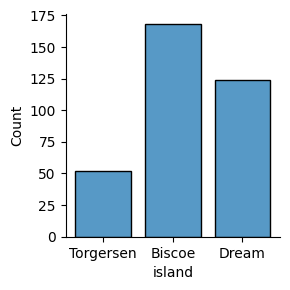

In [19]:
sns.displot(
    data=penguins,
    kind='hist', # Histogram
    discrete=True, shrink=0.8, # Categorical
    x='island', # Variable to plot on the x-axis
    height=3, aspect=1, # Figure size
)

### Proportions

When ccounts are relative to the whole, it is called **Proportion** ($\hat p$) or *Relative Frequency* and is often expressed in precentage (%).

$$
\hat{p} = \frac{n}{N}
$$

We can show this using `value_counts` with `normalize=True`, like so:

In [ ]:
penguins['island'].value_counts(normalize=True)

island
Biscoe       0.488372
Dream        0.360465
Torgersen    0.151163
Name: proportion, dtype: float64

It can be expressed in seaborn `displot` by setting `stat="probability"`:

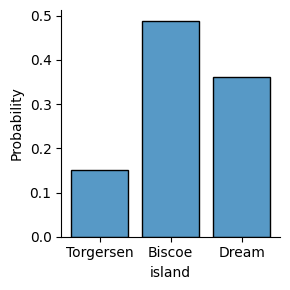

In [ ]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    x='island',
    height=3, aspect=1,
    stat='probability'  # Shows relative frequency
)

Notice how the bars are always proportional whether we are using counts or frequencies on the y-axis.

#### Include more categorical variables with `hue`

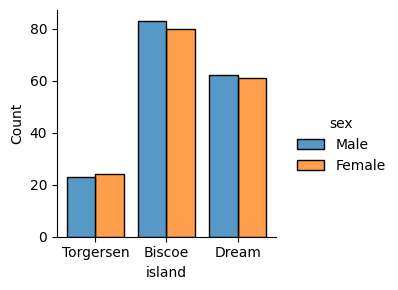

In [ ]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='island',
    hue='sex',        # Distinguish color by this categorical variable
    multiple='dodge', # Put next to each other (try: "stack" and "fill")
)

#### Include more categorical variables with `col` and `row`

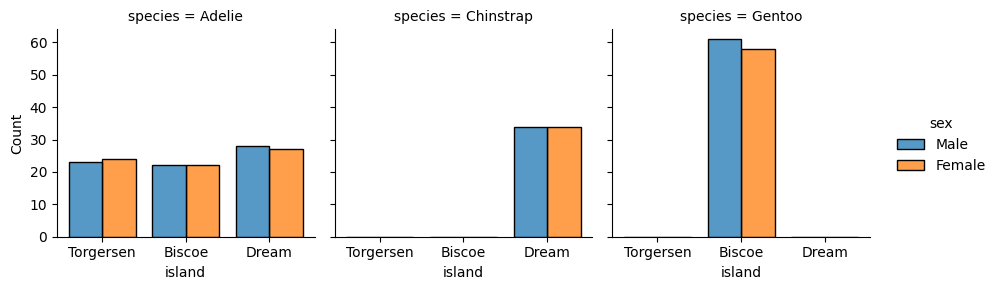

In [ ]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='island',
    hue='sex',
    multiple='dodge',
    col='species',    # Try row instead of col
)

## Statistics of numerical variable

We can use `df.describe()` method to get most statistics:

In [21]:
s = penguins['body_mass_g'].describe()
s

count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

We can then select whichever one of them:

In [23]:
print(s['mean'])

4201.754385964912


Or recalculate it indivdually:

In [24]:
m = penguins['body_mass_g'].mean()
print(m)

4201.754385964912


## Histogram

**Histogram** shows where the values of the variable `body_mass_g` lie on the x-axis, and how many of them are there (count).

Let's look at the value counts of height in meters `body_mass_g` (numerical):

In [ ]:
counts = penguins['body_mass_g'].value_counts()
counts

body_mass_g
3800.0    12
3700.0    11
3950.0    10
3900.0    10
3550.0     9
          ..
5450.0     1
4975.0     1
4575.0     1
4375.0     1
5750.0     1
Name: count, Length: 94, dtype: int64

### Binning

A histogram groups the values into **Bins** of uniform size before drawing the bar which represents how many values is in that bin.

In [ ]:
bins = pd.cut(penguins['body_mass_g'], bins=10)
bin_counts = bins.value_counts().sort_index()
bin_counts

body_mass_g
(2696.4, 3060.0]    15
(3060.0, 3420.0]    43
(3420.0, 3780.0]    71
(3780.0, 4140.0]    53
(4140.0, 4500.0]    45
(4500.0, 4860.0]    38
(4860.0, 5220.0]    28
(5220.0, 5580.0]    27
(5580.0, 5940.0]    16
(5940.0, 6300.0]     6
Name: count, dtype: int64

From seaborn, we select a `displot` (distribution plot) of `kind='hist'`:

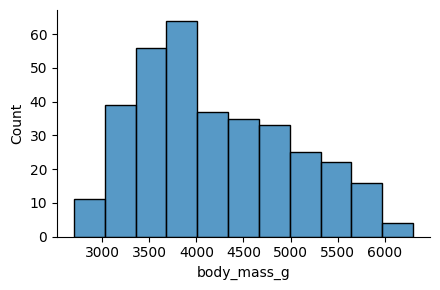

In [ ]:
sns.displot(
    penguins, kind='hist',
    x='body_mass_g',
    aspect=1.5, height=3
)


You may choose to adjust the size / number of bins in two ways:

- By Width: `binwidth=10`
- By Count: `bins=20`

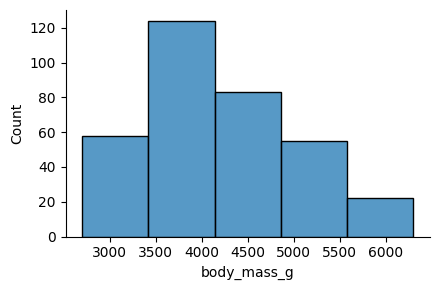

In [ ]:
sns.displot(
    penguins, kind='hist',
    x='body_mass_g',
    aspect=1.5, height=3,

    # binwidth=100, # by width
    bins=5,      # or by count
)


### KDE Plot

Sometimes we use the **Kernel Density Estimation plot** (KDE) instead to show the distrubtion:

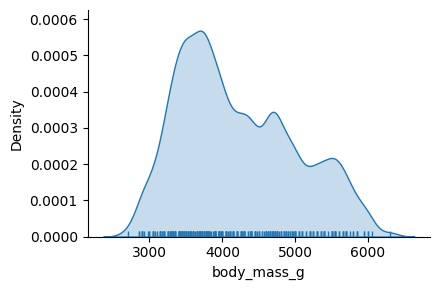

In [ ]:
sns.displot(
    penguins,
    x='body_mass_g',
    aspect=1.5, height=3,
    
    kind='kde',     # Curve
    fill=True,      # Fill-in with color
    rug=True,       # Show actual where samples are
    bw_adjust=0.45  # Curve smoothness
)

**Multi-modality**: we observe the shape showing multiple peaks, suggesting a mixure of distributions, which we can split using `hue`:

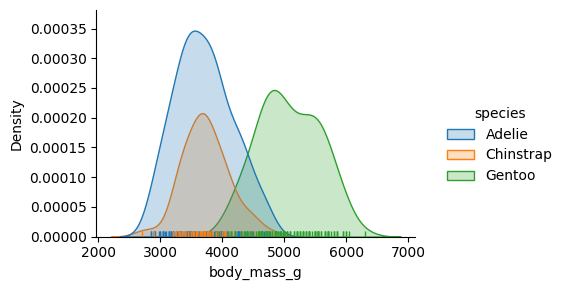

In [ ]:
sns.displot(
    penguins,
    kind='kde',
    fill=True,
    rug=True,
    aspect=1.5, height=3,

    x='body_mass_g', # Numerical
    hue='species',   # Categorical
)

It is also possible to draw each individual distribution in a separate subplot: by assigning the second variable to `col` or `row` rather than (or in addition to) `hue`:

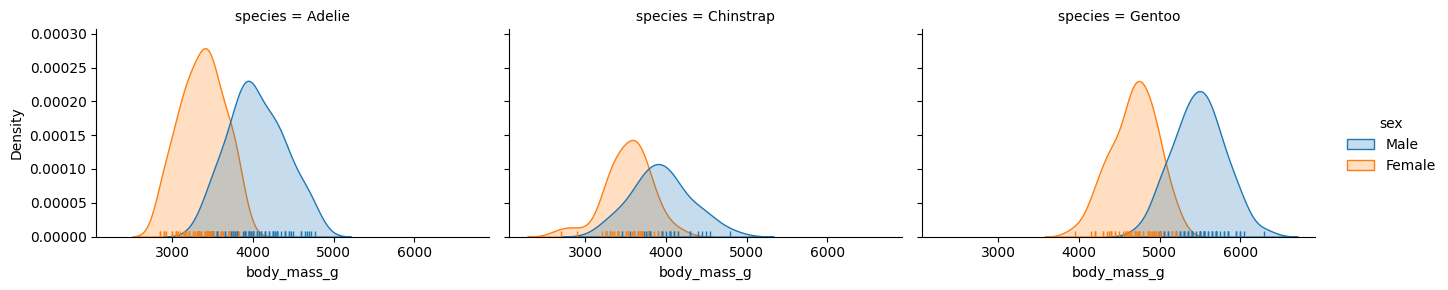

In [ ]:
sns.displot(
    penguins,
    kind='kde', fill=True, rug=True,
    aspect=1.5, height=3,
    
    x="body_mass_g", # Numerical
    hue="sex",       # Cateogrical
    col="species",   # Categorical
)